In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

In [6]:
# Gaussian function
# fit to get peak energy, width and height
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

In [25]:
# Data extracted from NOvA ND plot
x_values = np.array([0.38, 0.84, 1.04, 1.18, 1.24, 1.38, 1.42, 1.56, 1.62, 1.78, 1.82, 1.98, 2.16, 2.39, 2.61, 2.88, 3.24, 4.76, 4.5])
y_values = np.array([2, 26, 46, 60, 78, 94, 110, 124, 136, 142, 144, 139, 120, 80, 48, 26, 10, 4, 0.5])

# Initial guerss for fitting parameters
initial_guess = np.array([140,2,0.5])

Fitted parameters: Amplitude = 143.9478108222235, Mean = 1.8384983482522512, Sigma = 0.5273664472026398


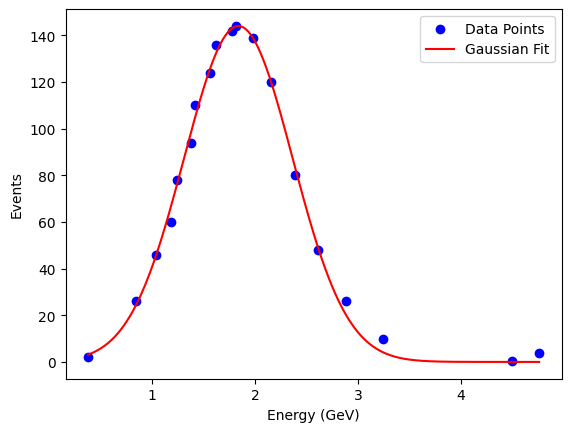

In [38]:
# Perform the curve fit
popt, pcov = curve_fit(gaus, x_values, y_values, p0=initial_guess)

# Extract the best-fit parameters
amplitude, mean, sigma = popt
print(f"Fitted parameters: Amplitude = {amplitude}, Mean = {mean}, Sigma = {sigma}")

# Generate Gaussian fit for plotting
x_fit = np.linspace(min(x_values), max(x_values), 1000)
y_fit = gaus(x_fit, amplitude, mean, sigma)

# Plot the original data and the Gaussian fit
plt.scatter(x_values, y_values, label="Data Points", color="blue")
plt.plot(x_fit, y_fit, label="Gaussian Fit", color="red")
plt.xlabel("Energy (GeV)")
plt.ylabel("Events")
plt.legend()
plt.show()

In [39]:
# Oscillation function (Survival probability)
def osc(bin_centers,sin22theta,deltam2):
    L = 1000.0
    return (1 - (sin22theta * (np.sin((1.27 * deltam2 * L) / bin_centers) ** 2)))

Oscillated Neutrino events for the far detector: [ 0 33 51 41 47 38 36 19  9  1  2  0  6 12 14  8  3  0  0]


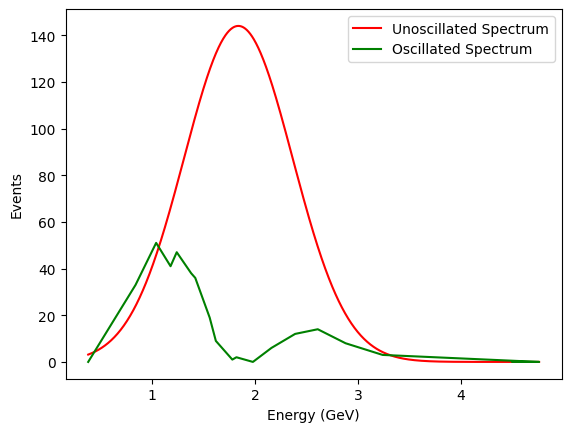

In [37]:
# Apply oscillation to the data points
y_oscillated = np.random.poisson(osc(x_values,1,2.4e-3)*gaus(x_values, *popt))
print('Oscillated Neutrino events for the far detector:',y_oscillated)

# Plot the oscillated spectrum
plt.plot(x_fit, y_fit, label="Unoscillated Spectrum", color="red")
plt.plot(x_values, y_oscillated, label="Oscillated Spectrum", color="green")
plt.xlabel("Energy (GeV)")
plt.ylabel("Events")
plt.legend()
plt.show()